# AG-HYPOPT · Trial 04

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Three trials, all bandwidth-free 2-D families at `sigma_weight` ~0.41-0.43, all worse than the frozen
KDE control (0.080328): **trial_01** `w1_2d` -> **0.0895** (mu-heavy low-count error), **trial_02**
`energy_2d` -> **0.0996** (systematic low-count gamma undershoot), **trial_03** `mmd_2d` -> **0.1833**
(mu low at every transmission, by far the worst). No divergences in any trial. Ranked so far:
`kde` (ref 0.0803) < `w1_2d` (0.0895) < `energy_2d` (0.0996) < `mmd_2d` (0.1833). The FWHM-only
controls (`w1_fwhm`, `cvm_fwhm`) and the `kde` control itself have no trial yet; phase still `uniform`
(3/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_04'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (3/5 trials)
ID |     ei | params
 1 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.5113275528143616}
 2 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.9762437057077041}
 3 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.6073558319950296}
 4 |      - | {"loss_family": "kde", "sigma_weight": 0.37648658437727256}
 5 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.17452781614402846}
 6 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.8716352741876564}
 7 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.9022150797159884}
 8 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.4771535238392063}
 9 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.7889467175443294}
10 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.9841529999311214}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Three S-D families have points (all at sw ~0.41-0.43); the FWHM-only controls and the `kde` control do
not. The most informative next step is the FWHM-only control inside the strongest S-D family so far,
`w1_2d`: `w1_fwhm` drops the sigma channel entirely, so comparing it with trial_01's `w1_2d` (0.0895)
at a similar sw isolates exactly what the sigma link contributes.

Scanning the table: candidates 2, 3, 9 are `cvm_fwhm` (the other FWHM-only control - worth one trial,
but not yet); 4 is `kde` (the control - re-anchors 0.0803, useful as a verification later); 5 and 8 are
more `mmd_2d` (already clearly the worst, low value); 7 more `w1_2d`; 10 more `energy_2d`. Candidate 1
is `w1_fwhm` at sw 0.511 - the clean FWHM-only counterpart to trial_01, and the family whose two-channel
version is currently the best alternative. (For the FWHM-only families the sigma channel is absent, so
`sigma_weight` should be inert; any `w1_fwhm` candidate plays the same role.)

I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'w1_fwhm', 'sigma_weight': 0.5113275528143616}
Running  1nW Trans05 ... 

μ 9.39 -> 5.62 | γ 8.5 -> 2.81 | NLL 16.72


Running  1nW Trans20 ... 

μ 17.32 -> 26.20 | γ 8.5 -> 5.69 | NLL 3.76


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.15 | γ 14.1 -> 14.49 | NLL 1.67


Running 3nW Trans100 ... 

μ 175.71 -> 98.62 | γ 14.1 -> 13.77 | NLL 2.20



Total: 7.7 min


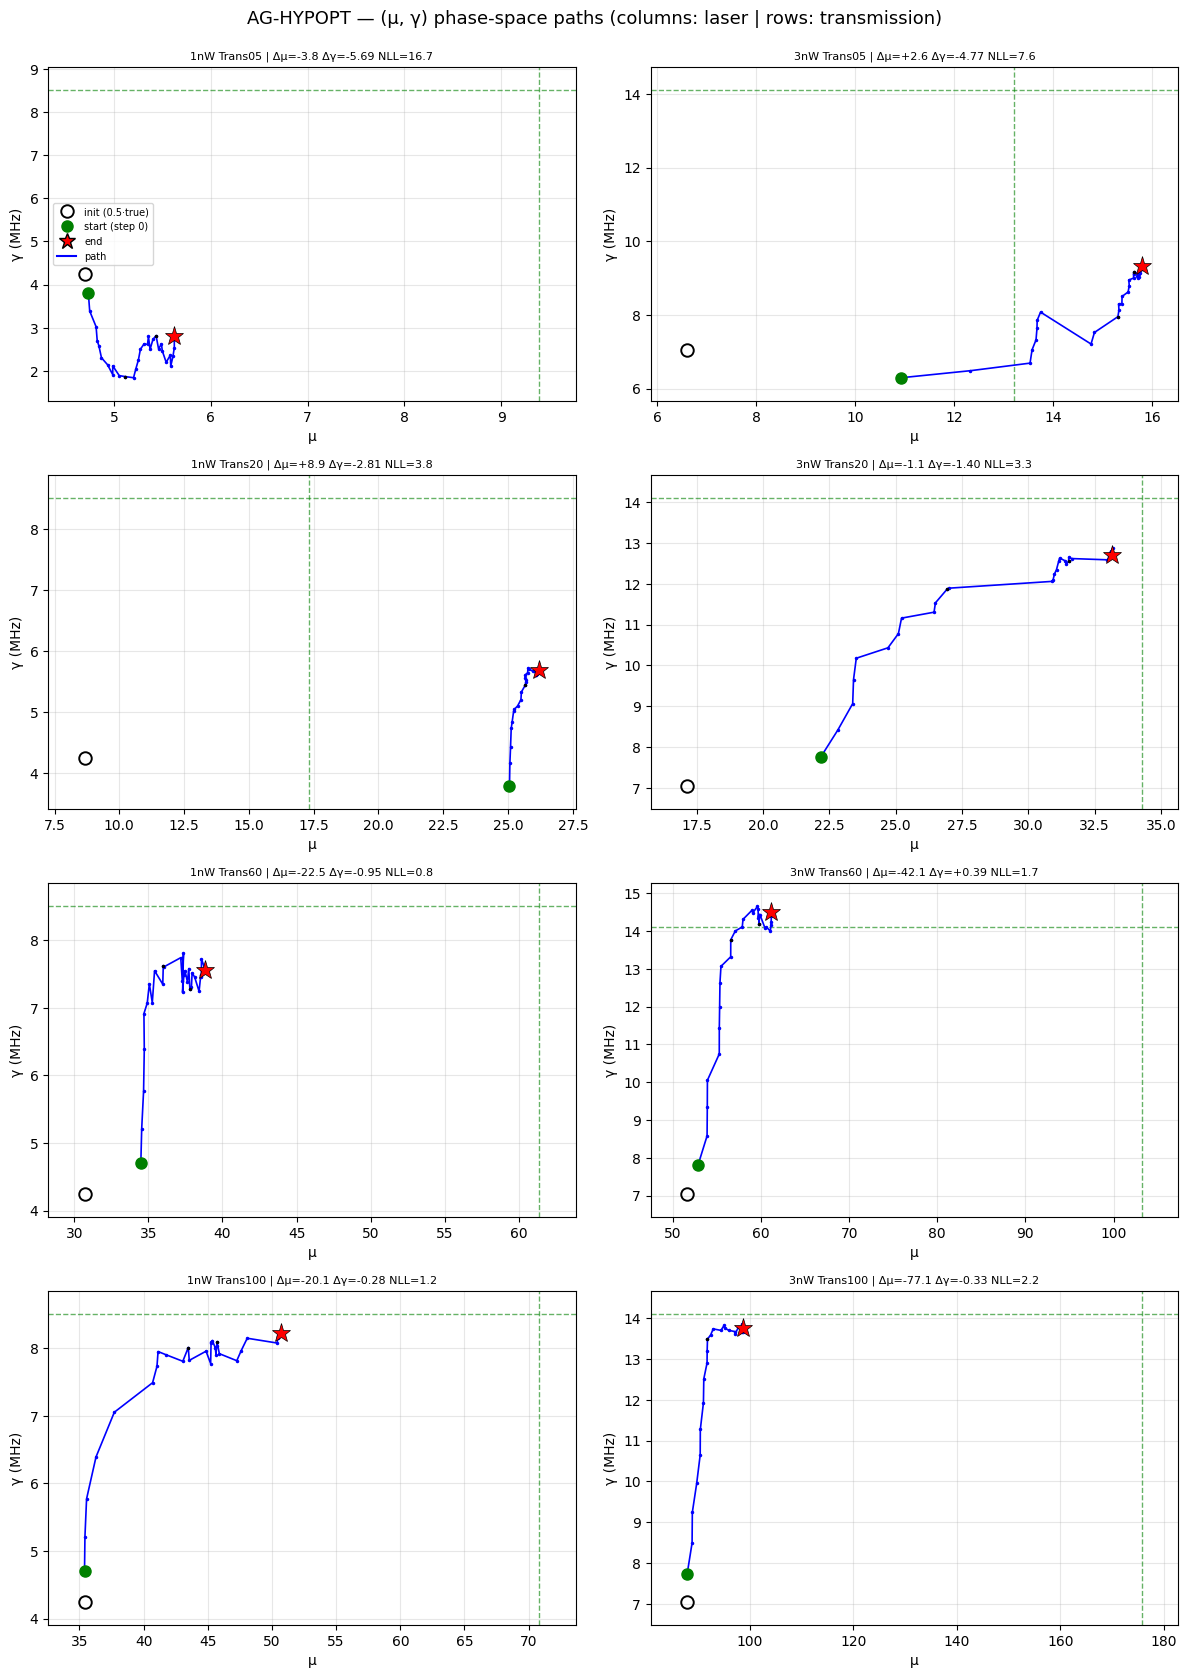

trial finished in 7.7 min
objective = 0.0908 ± 0.0305
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.62   -40.1 |     8.50    2.81   -66.9
1nW Trans20       17.32   26.20   +51.3 |     8.50    5.69   -33.0
1nW Trans60       61.37   38.84   -36.7 |     8.50    7.55   -11.1
1nW Trans100       70.82   50.69   -28.4 |     8.50    8.22    -3.3
3nW Trans05       13.20   15.79   +19.6 |    14.10    9.33   -33.8
3nW Trans20       34.28   33.15    -3.3 |    14.10   12.70    -9.9
3nW Trans60      103.20   61.15   -40.7 |    14.10   14.49    +2.8
3nW Trans100      175.71   98.62   -43.9 |    14.10   13.77    -2.4

weighted objective (T-graded, cap=1.0) = 0.0908 | diverged cells: 0
μ: RMSE 33.025 (rel 36.0%, bias -19.404) | γ: RMSE 2.876 (rel 29.5%, bias -1.979)


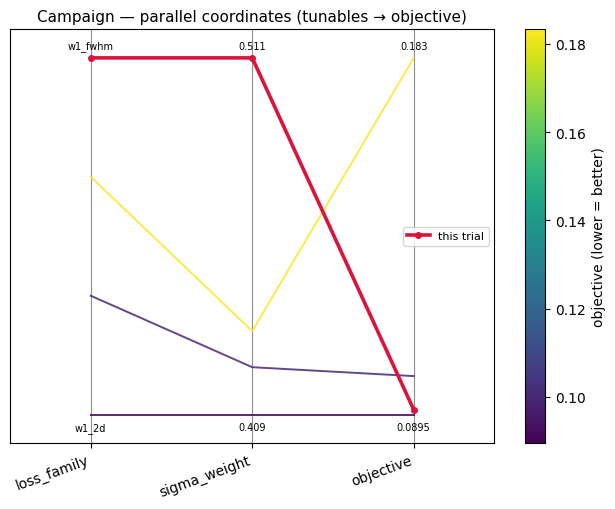

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'w1_fwhm', sigma_weight: 0.5113}` (candidate 1). Trial time
7.7 min, objective **0.0908 +/- 0.0305**, **0 diverged cells**. This is the FWHM-only counterpart of
trial_01's `w1_2d` (0.0895 at sw 0.409); the two are statistically indistinguishable and both remain
above the KDE control (0.0803). Note that for the FWHM-only families the sigma channel is absent, so
the sampled `sigma_weight` is inert - this trial is effectively `w1_fwhm` plain.

**Per-cell behaviour.** Almost a carbon copy of trial_01, i.e. the sigma channel's presence/absence
barely moved anything:

- 1nW Trans05: mu -40.1 %, gamma 8.5 -> 2.81 (-66.9 %) (trial_01: -36.5 % / -61.0 %).
- 1nW Trans20: mu +51.3 %, gamma -33.0 % (trial_01: +65.9 % / -31.2 %).
- 1nW Trans60 / Trans100: mu -36.7 % / -28.4 %, gamma -11.1 % / -3.3 %.
- 3nW Trans05 / Trans20: mu +19.6 % / -3.3 %, gamma -33.8 % / -9.9 %.
- 3nW Trans60 / Trans100: mu -40.7 % / -43.9 %, gamma +2.8 % / -2.4 %.

**Aggregates.** mu: RMSE 33.03 (rel 36.0 %), bias -19.40; gamma: RMSE 2.88 (rel 29.5 %), bias -1.98.
Compare trial_01 (`w1_2d`): mu 32.33 (rel 38.3 %), gamma 2.64 (rel 27.1 %) - again essentially tied.

**Summary:** `w1_fwhm` (sw 0.511) reaches objective 0.0908, statistically identical to the two-channel
`w1_2d` (0.0895) and still worse than the KDE control (0.0803), with no divergences.
**Key insight:** Dropping the sigma channel from the W1 loss changes the result essentially not at all
(0.0908 vs 0.0895), so the W1 shortfall is a property of the FWHM loss itself, not of the sigma link.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'w1_fwhm (sigma_weight 0.5113) reaches objective 0.0908, statistically identical to the two-channel w1_2d (0.0895) and still worse than the KDE control (0.0803), with no divergences.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'Dropping the sigma channel from the W1 loss changes the result essentially not at all (0.0908 vs 0.0895), so the W1 shortfall is a property of the FWHM loss itself, not of the sigma link.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_04 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_05.ipynb. Open it and follow its cells from the top.
